In [ ]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_DIR = "/content/drive/MyDrive/final_project/dataset"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")

IMG_SIZE = (224,224)
BATCH_SIZE = 16
EPOCHS = 30
NUM_CLASSES = 3

In [ ]:
print("Train Classes:", os.listdir(TRAIN_DIR))
print("Val Classes:", os.listdir(VAL_DIR))
print("Test Classes:", os.listdir(TEST_DIR))

Train Classes: ['MEL', 'BKL', 'NV']
Val Classes: ['NV', 'BKL', 'MEL']
Test Classes: ['MEL', 'NV', 'BKL']


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.25,
    horizontal_flip=True,
    shear_range=0.15
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 4800 images belonging to 3 classes.
Found 600 images belonging to 3 classes.
Found 600 images belonging to 3 classes.


In [ ]:
custom_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(NUM_CLASSES, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
custom_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

custom_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,828,547 (37.49 MB)

 Trainable params: 9,827,587 (37.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

In [ ]:
history = custom_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 4588s 15s/step - accuracy: 0.4561 - loss: 2.1579 - val_accuracy: 0.4067 - val_loss: 2.4717
Epoch 2/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 112s 373ms/step - accuracy: 0.5165 - loss: 1.0251 - val_accuracy: 0.5600 - val_loss: 0.9547
Epoch 3/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 112s 372ms/step - accuracy: 0.5511 - loss: 0.9322 - val_accuracy: 0.5617 - val_loss: 0.9141
Epoch 4/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 111s 370ms/step - accuracy: 0.5573 - loss: 0.9201 - val_accuracy: 0.5483 - val_loss: 0.9375
Epoch 5/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 111s 371ms/step - accuracy: 0.5595 - loss: 0.9314 - val_accuracy: 0.4950 - val_loss: 1.0102
Epoch 6/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 112s 374ms/step - accuracy: 0.5721 - loss: 0.9034 - val_accuracy: 0.5850 - val_loss: 0.8870
Epoch 7/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 113s 378ms/step - accuracy: 0.5606 - loss: 0.9172 - val_accuracy: 0.5400 - val_loss: 0.9303
Epoch 8/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 113s 377ms/step - accuracy: 0.5679 - 

In [ ]:
test_loss, test_acc = custom_model.evaluate(test_generator)

print("\nTest Accuracy:", test_acc)

38/38 ━━━━━━━━━━━━━━━━━━━━ 484s 13s/step - accuracy: 0.7175 - loss: 0.6920

Test Accuracy: 0.6700000166893005


In [ ]:
custom_model.save("/content/drive/MyDrive/final_project/custom_cnn_model.h5")
custom_model.save("/content/drive/MyDrive/final_project/custom_cnn_model.keras")

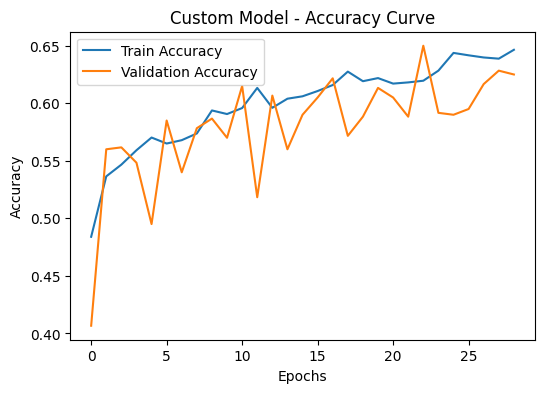

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Custom Model - Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

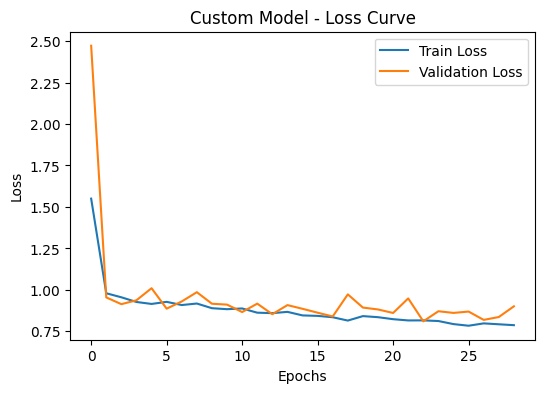

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Custom Model - Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 282ms/step


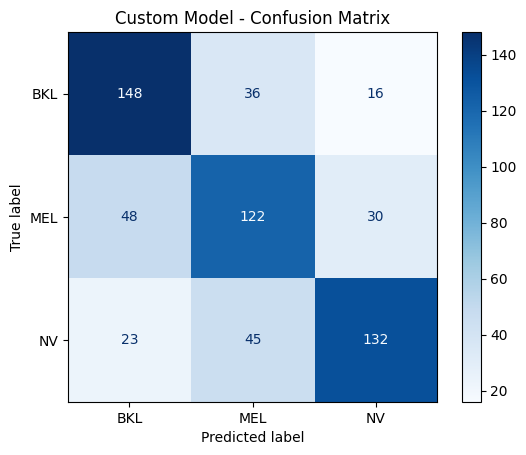

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = test_generator.classes
y_probs = custom_model.predict(test_generator)
y_pred = np.argmax(y_probs, axis=1)

class_names = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title("Custom Model - Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

report = classification_report(
    y_true, y_pred,
    target_names=class_names,
    output_dict=True
)

print("\n====== CUSTOM MODEL - METRICS TABLE ======\n")
print("{:<12} {:<10} {:<10} {:<10} {:<12} {:<10} {:<10}".format(
    "Class", "Precision", "Recall", "F1-Score", "Specificity", "IoU", "Dice"
))

specificity_list = []
iou_list = []

for i, cls in enumerate(class_names):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

    precision = report[cls]['precision']
    recall = report[cls]['recall']
    f1 = report[cls]['f1-score']

    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0
    iou = TP / (TP + FP + FN) if (TP + FP + FN) != 0 else 0
    dice = (2 * TP) / (2 * TP + FP + FN) if (2 * TP + FP + FN) != 0 else 0

    specificity_list.append(specificity)
    iou_list.append(iou)

    print("{:<12} {:<10.6f} {:<10.6f} {:<10.6f} {:<12.6f} {:<10.6f} {:<10.6f}".format(
        cls, precision, recall, f1, specificity, iou, dice
    ))

# Overall metrics
overall_accuracy = accuracy_score(y_true, y_pred)
mean_iou = np.mean(iou_list)

print("\nCustom Model Accuracy: {:.4f}".format(overall_accuracy))
print("Custom Model Mean IoU: {:.4f}".format(mean_iou))


====== CUSTOM MODEL - METRICS TABLE ======

Class        Precision  Recall     F1-Score   Specificity  IoU        Dice      
BKL          0.675799   0.740000   0.706444   0.822500     0.546125   0.706444  
MEL          0.600985   0.610000   0.605459   0.797500     0.434164   0.605459  
NV           0.741573   0.660000   0.698413   0.885000     0.536585   0.698413  

Custom Model Accuracy: 0.6700
Custom Model Mean IoU: 0.5056


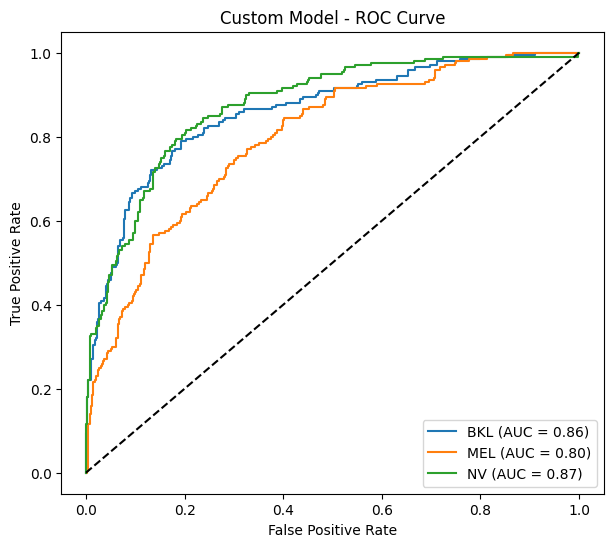

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

num_classes = len(class_names)
y_bin = label_binarize(y_true, classes=range(num_classes))

plt.figure(figsize=(7,6))

for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Custom Model - ROC Curve")
plt.legend()
plt.show()